In [1]:
!pip install tensorflow opencv-python matplotlib kagglehub

In [2]:
import kagglehub


path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to: /kaggle/input/plantdisease


In [3]:
import os
import cv2
import numpy as np

IMG_SIZE = 64
SEQUENCE_LENGTH = 5

data = []
labels = []


dataset_path = path

print("Main Path:", dataset_path)


print("Folders:", os.listdir(dataset_path))


dataset_folder = os.path.join(dataset_path, os.listdir(dataset_path)[0])

print("Dataset Folder:", dataset_folder)

temp_sequence = []


for folder_name in os.listdir(dataset_folder):

    folder_path = os.path.join(dataset_folder, folder_name)

    if not os.path.isdir(folder_path):
        continue

    print("Reading Folder:", folder_name)


    if "healthy" in folder_name.lower():
        label = 0
    else:
        label = 1

    images = os.listdir(folder_path)

    count = 0

    for img_name in images:

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0

        temp_sequence.append(img)


        if len(temp_sequence) == SEQUENCE_LENGTH:

            data.append(temp_sequence)
            labels.append(label)

            temp_sequence = []

        count += 1


        if count >= 50:
            break

X = np.array(data)
y = np.array(labels)

print("\nDataset Loaded Successfully")
print("X Shape:", X.shape)
print("y Shape:", y.shape)

Main Path: /kaggle/input/plantdisease
Folders: ['PlantVillage', 'plantvillage']
Dataset Folder: /kaggle/input/plantdisease/PlantVillage
Reading Folder: Pepper__bell___Bacterial_spot
Reading Folder: Potato___healthy
Reading Folder: Tomato_Leaf_Mold
Reading Folder: Tomato__Tomato_YellowLeaf__Curl_Virus
Reading Folder: Tomato_Bacterial_spot
Reading Folder: Tomato_Septoria_leaf_spot
Reading Folder: Tomato_healthy
Reading Folder: Tomato_Spider_mites_Two_spotted_spider_mite
Reading Folder: Tomato_Early_blight
Reading Folder: Tomato__Target_Spot
Reading Folder: Pepper__bell___healthy
Reading Folder: Potato___Late_blight
Reading Folder: Tomato_Late_blight
Reading Folder: Potato___Early_blight
Reading Folder: Tomato__Tomato_mosaic_virus

Dataset Loaded Successfully
X Shape: (150, 5, 64, 64, 3)
y Shape: (150,)


In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 5, 64, 64, 3)
Testing Data: (30, 5, 64, 64, 3)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed,
    Conv2D,
    MaxPooling2D,
    Flatten,
    LSTM,
    Dense,
    Dropout
)

model = Sequential()


model.add(TimeDistributed(
    Conv2D(32, (3,3), activation='relu'),
    input_shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
))

model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(
    Conv2D(64, (3,3), activation='relu')
))

model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(Flatten()))


model.add(LSTM(64))

model.add(Dropout(0.5))


model.add(Dense(32, activation='relu'))

model.add(Dense(2, activation='softmax'))


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 62, 62, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 31, 31, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 29, 29, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 5, 14, 14, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 12544)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     3,227,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,249,442 (12.40 MB)

 Trainable params: 3,249,442 (12.40 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8167 - loss: 0.5856 - val_accuracy: 0.7333 - val_loss: 0.5755
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8167 - loss: 0.5120 - val_accuracy: 0.7333 - val_loss: 0.5755
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8167 - loss: 0.5609 - val_accuracy: 0.7333 - val_loss: 0.5655
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8167 - loss: 0.5165 - val_accuracy: 0.7333 - val_loss: 0.5761
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8167 - loss: 0.4521 - val_accuracy: 0.7333 - val_loss: 0.5559


In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7333 - loss: 0.5559
Test Accuracy: 0.7333333492279053


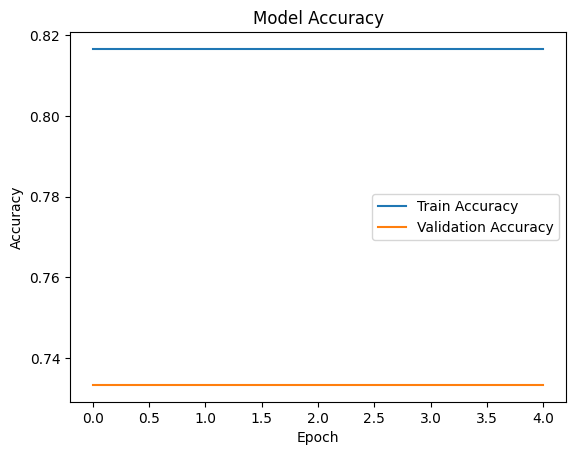

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy", "Validation Accuracy"])

plt.show()

In [10]:
prediction = model.predict(X_test[:1])

print("Prediction Values:", prediction)

predicted_class = np.argmax(prediction)

if predicted_class == 0:
    print("Healthy Crop")
else:
    print("Diseased Crop")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
Prediction Values: [[0.2565616 0.7434384]]
Diseased Crop


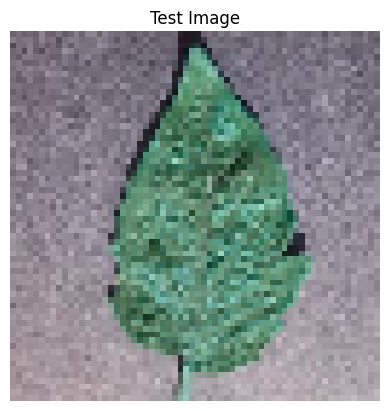

In [11]:
sample_image = X_test[0][0]

plt.imshow(sample_image)
plt.title("Test Image")
plt.axis("off")

plt.show()